# 01 — Exploratory Data Analysis

Goal: understand the raw creditcard dataset before touching a model.
Outputs feed directly into feature engineering decisions in notebook 03.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

FIGURES_PATH = Path('../outputs/figures')
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

df = pd.read_csv('../data/raw/creditcard.csv')
print(f"Loaded {df.shape[0]:,} rows, {df.shape[1]} columns")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\New User\AppData\Roaming\Pyth

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\New User\AppData\Roaming\Pyth

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Loaded 284,807 rows, 31 columns


## 1. Basic structure

In [2]:
print(df.dtypes)
df.head(3)

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [3]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total missing: 0


## 2. Class balance

Legitimate : 284,315
Fraud      : 492
Fraud rate : 0.1727%


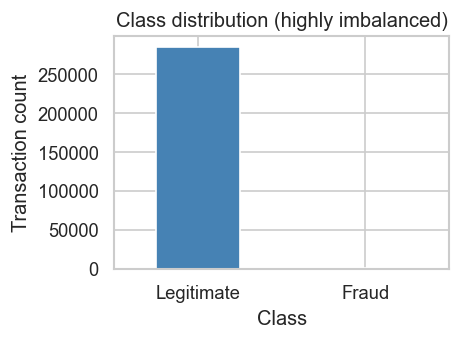


Class imbalance ratio: 578:1  (legit:fraud)


In [4]:
class_counts = df['Class'].value_counts()
fraud_rate = df['Class'].mean() * 100
print(f"Legitimate : {class_counts[0]:,}")
print(f"Fraud      : {class_counts[1]:,}")
print(f"Fraud rate : {fraud_rate:.4f}%")

fig, ax = plt.subplots(figsize=(4, 3))
class_counts.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='white')
ax.set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
ax.set_title('Class distribution (highly imbalanced)')
ax.set_xlabel('Class')
ax.set_ylabel('Transaction count')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '01_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClass imbalance ratio: {class_counts[0]/class_counts[1]:.0f}:1  (legit:fraud)")

## 3. Amount distribution

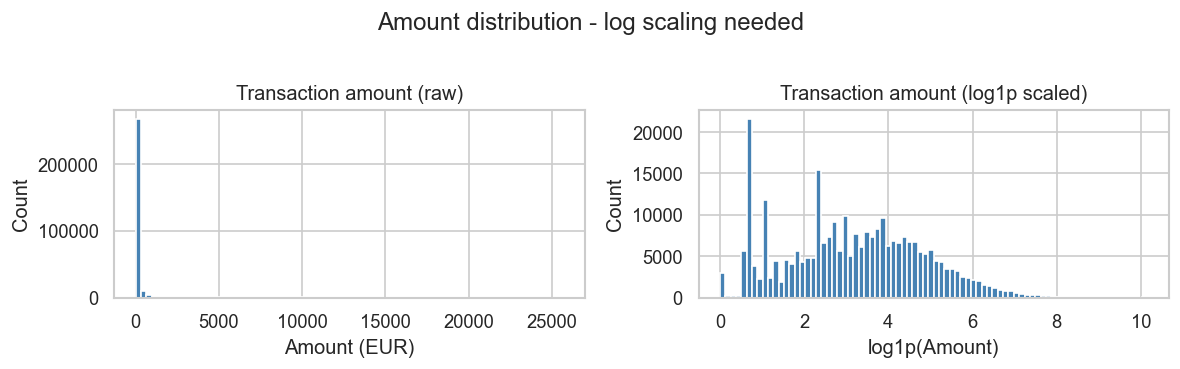

Raw amount  - mean: 88.35, median: 22.00, max: 25691.16
Fraud mean  : 122.21
Legit mean  : 88.29


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

df['Amount'].hist(bins=80, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Transaction amount (raw)')
axes[0].set_xlabel('Amount (EUR)')
axes[0].set_ylabel('Count')

np.log1p(df['Amount']).hist(bins=80, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Transaction amount (log1p scaled)')
axes[1].set_xlabel('log1p(Amount)')
axes[1].set_ylabel('Count')

plt.suptitle('Amount distribution - log scaling needed', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH / '01_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Raw amount  - mean: {df['Amount'].mean():.2f}, median: {df['Amount'].median():.2f}, max: {df['Amount'].max():.2f}")
print(f"Fraud mean  : {df[df['Class']==1]['Amount'].mean():.2f}")
print(f"Legit mean  : {df[df['Class']==0]['Amount'].mean():.2f}")

## 4. Time feature — hour-of-day fraud rate

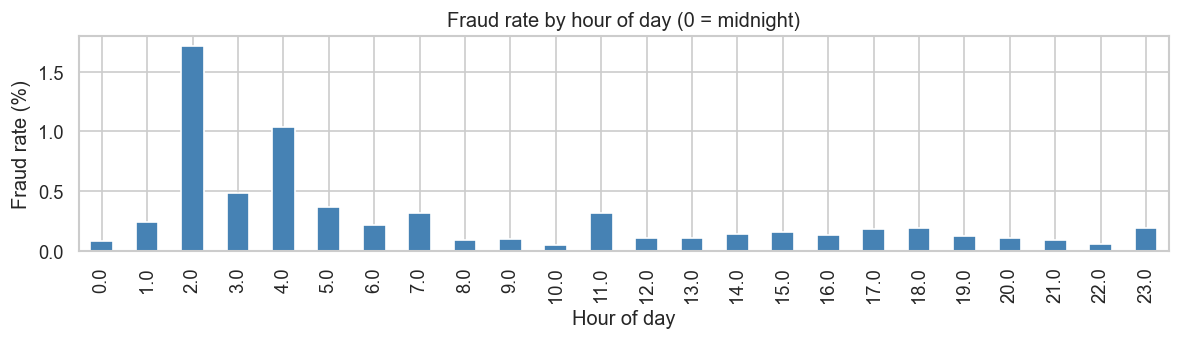

Peak fraud hour: 2.0:00  (1.713%)


In [6]:
df['hour_of_day'] = (df['Time'] // 3600) % 24

hourly = df.groupby('hour_of_day')['Class'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 3))
hourly.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Fraud rate by hour of day (0 = midnight)')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Fraud rate (%)')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '01_fraud_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

peak_hour = hourly.idxmax()
print(f"Peak fraud hour: {peak_hour}:00  ({hourly[peak_hour]:.3f}%)")

## 5. Feature correlations with Class

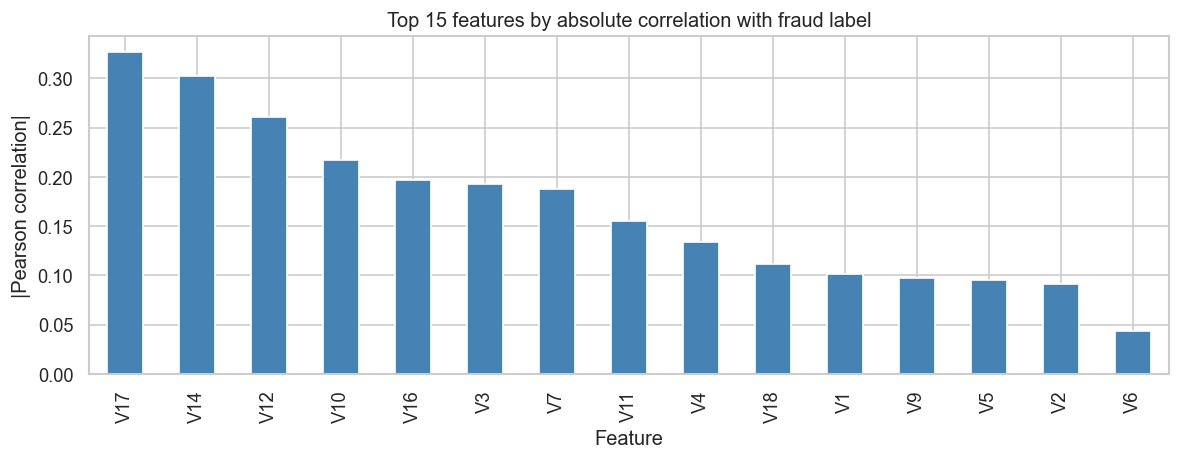

Top 10 features correlated with fraud:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485


In [7]:
correlations = df.drop(columns=['Time', 'hour_of_day']).corr()['Class'].drop('Class')
correlations_sorted = correlations.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
correlations_sorted.head(15).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 features by absolute correlation with fraud label')
ax.set_xlabel('Feature')
ax.set_ylabel('|Pearson correlation|')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '01_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 features correlated with fraud:")
print(correlations_sorted.head(10).to_string())

## 6. PCA feature separation — top 3 vs Class

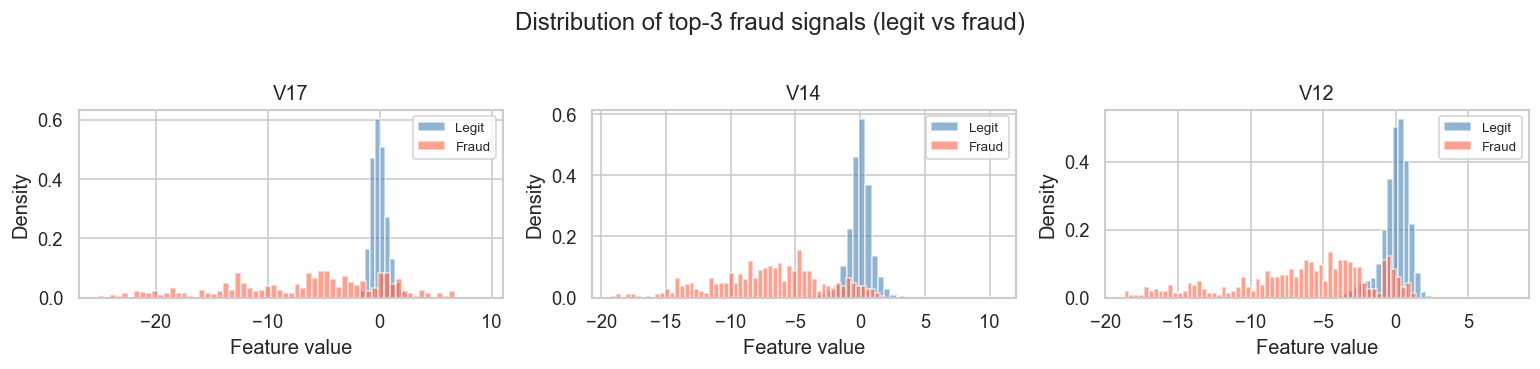

In [8]:
top3 = correlations_sorted.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, feat in zip(axes, top3):
    df[df['Class']==0][feat].hist(bins=60, ax=ax, alpha=0.6, label='Legit',
                                   color='steelblue', density=True)
    df[df['Class']==1][feat].hist(bins=60, ax=ax, alpha=0.6, label='Fraud',
                                   color='tomato', density=True)
    ax.set_title(feat)
    ax.set_xlabel('Feature value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
plt.suptitle('Distribution of top-3 fraud signals (legit vs fraud)', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH / '01_top3_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. EDA summary

In [9]:
print("=" * 55)
print("EDA SUMMARY")
print("=" * 55)
print(f"\n1. CLASS IMBALANCE")
print(f"   Fraud rate: {fraud_rate:.4f}% - use class_weight or SMOTE.")
print(f"   Accuracy is a useless metric here; use PR-AUC.")
print(f"\n2. AMOUNT")
print(f"   Median: {df['Amount'].median():.2f}")
print(f"   Amount needs log scaling before modelling.")
print(f"\n3. TIME")
print(f"   Fraud rate varies by hour - time is a useful feature.")
print(f"   Convert raw seconds to hour-of-day.")
print(f"\n4. FEATURES")
top3 = correlations_sorted.head(3).index.tolist()
print(f"   Strongest fraud signals: {top3}")
print(f"   These PCA features show clear class separation.")
print(f"\n5. MISSING DATA")
print(f"   {df.isnull().sum().sum()} missing values - no imputation needed.")
print(f"\nNext: notebook 02 - build a baseline logistic regression model.")
print("=" * 55)

EDA SUMMARY

1. CLASS IMBALANCE
   Fraud rate: 0.1727% - use class_weight or SMOTE.
   Accuracy is a useless metric here; use PR-AUC.

2. AMOUNT
   Median: 22.00
   Amount needs log scaling before modelling.

3. TIME
   Fraud rate varies by hour - time is a useful feature.
   Convert raw seconds to hour-of-day.

4. FEATURES
   Strongest fraud signals: ['V17', 'V14', 'V12']
   These PCA features show clear class separation.

5. MISSING DATA
   0 missing values - no imputation needed.

Next: notebook 02 - build a baseline logistic regression model.
